# Exploratory_Data_Analysis

## 1. 项目背景

- 目标: 功率预测 
- 目标变量 (TARGETVAR）)：10个澳大利亚风电场的真实发电功率 （其中选取1号风电场作为预测对象）
- 数据集: 
    - 训练集：Task15_W_Zone1.csv
    - 测试集：
        - 数据：TaskExpVars15_W_Zone1.csv
        - 标签：solution15_W.csv
- 特征: 
    - 数据来源：欧洲中期天气预报中心（ECMWF）给出的气象预报。
    - U10, V10：10米高度的 zonal (东西向) 和 meridional (南北向) 风速分量。
    - U100, V100：100米高度的的 zonal (东西向) 和 meridional (南北向) 风速分量。

## 2. 数据概览

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# 2.1 Load train data
df_train = pd.read_csv('data/Interim/train.csv')

In [25]:
# 2.2 Shape & Columns
print("Shape: ",df_train.shape)
print("Columns: ",df_train.columns)
df_train.sample(5) 

Shape:  (16800, 7)
Columns:  Index(['ZONEID', 'TIMESTAMP', 'TARGETVAR', 'U10', 'V10', 'U100', 'V100'], dtype='object')


,ZONEID,TIMESTAMP,TARGETVAR,U10,V10,U100,V100
14100,1,20130810 13:00,0.252420,1.911094,-1.691751,5.012397,-3.769437
1414,1,20120228 23:00,0.557090,-3.611291,3.456916,-5.154892,4.811136
8240,1,20121209 9:00,0.300442,-1.398314,4.560105,-2.353309,7.375510
12211,1,20130523 20:00,0.031858,0.081916,-0.099817,0.189657,1.209426
11443,1,20130421 20:00,0.530683,3.967221,-0.715470,7.033027,-0.781698


In [26]:
# 2.3 Data Types
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16800 entries, 0 to 16799
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ZONEID     16800 non-null  int64  
 1   TIMESTAMP  16800 non-null  object 
 2   TARGETVAR  16789 non-null  float64
 3   U10        16800 non-null  float64
 4   V10        16800 non-null  float64
 5   U100       16800 non-null  float64
 6   V100       16800 non-null  float64
dtypes: float64(5), int64(1), object(1)
memory usage: 918.9+ KB


In [27]:
# 2.4 Summary Statistics
df_train.describe()

,ZONEID,TARGETVAR,U10,V10,U100,V100
count,16800.0,16789.000000,16800.000000,16800.000000,16800.000000,16800.000000
mean,1.0,0.303299,0.935519,-0.250466,1.568721,-0.554659
std,0.0,0.289629,2.556424,2.919984,4.266318,5.028343
min,1.0,0.000000,-7.494252,-9.993858,-10.910809,-15.294866
25%,1.0,0.063434,-1.062387,-2.337600,-1.746650,-4.613866
50%,1.0,0.206935,0.788789,-0.039825,1.487808,0.132922
75%,1.0,0.479560,2.585812,1.927597,4.682327,3.488219
max,1.0,1.000000,11.117029,9.508798,16.988418,14.314416


## 3. 数据清洗

In [28]:
# 3.1.1 检查缺失值
df_train.isnull().sum()

ZONEID        0
TIMESTAMP     0
TARGETVAR    11
U10           0
V10           0
U100          0
V100          0
dtype: int64

In [30]:
# 3.1.2 缺失值处理 
# 在 16,800 条样本中，发现 11 条 TARGETVAR 缺失。鉴于缺失率极低，建议直接删除这些样本。
df_train = df_train.dropna(subset=['TARGETVAR'])

# 确认删除后的数据shape
print("New shape of dataframe:", df_train.shape)

New shape of dataframe: (16789, 7)


In [31]:
# 3.2 检查重复数据
df_train.duplicated().sum()

np.int64(0)

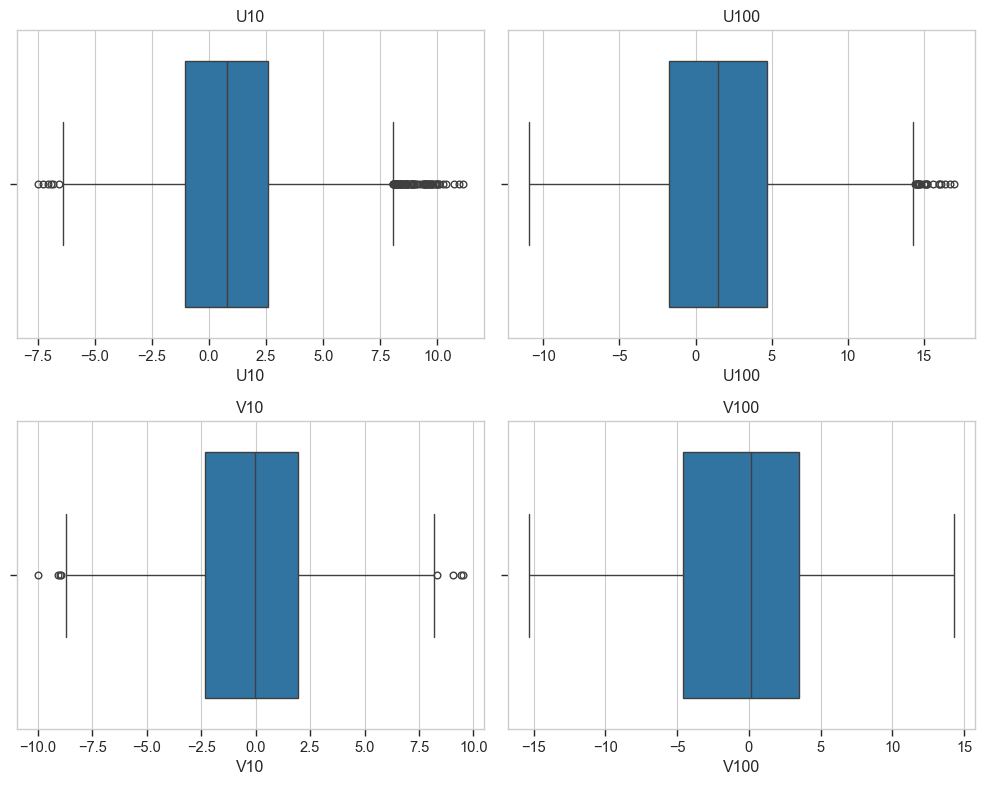

In [42]:
# 3.3 异常值检测：使用箱线图查看数值型特征的分布和异常值
# 设置图表风格
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
cols = ['U10', 'U100', 'V10', 'V100']

for ax, col in zip(axes.flat, cols):
    sns.boxplot(x=df_train[col], ax=ax)
    ax.set_title(f'{col}')

plt.tight_layout()
plt.show()

### 4. 时间特征分析

Text(0.5, 1.0, 'Wind Power over Time (ZONEID = 1)')

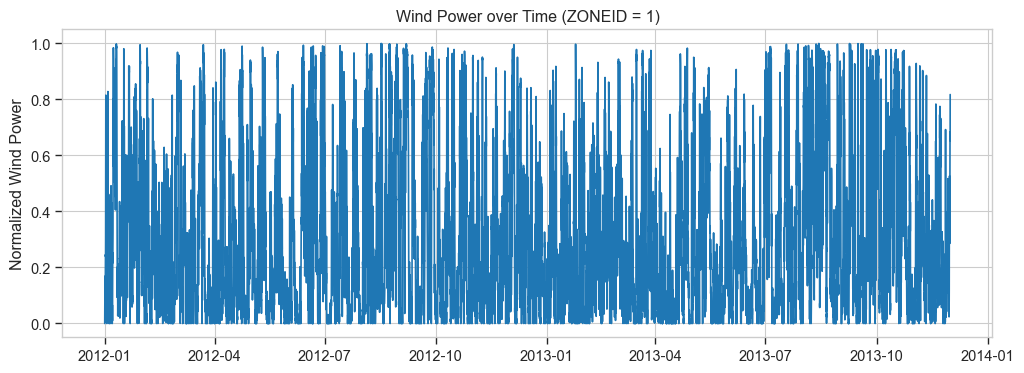

In [43]:
# 4.1 时间序列分析：
# 转时间
df_train['TIMESTAMP'] = pd.to_datetime(df_train['TIMESTAMP'])
df_train = df_train.sort_values('TIMESTAMP').reset_index(drop=True)

# 时间序列图
plt.figure(figsize=(12,4))
plt.plot(df_train['TIMESTAMP'], df_train['TARGETVAR'])
plt.ylabel("Normalized Wind Power")
plt.title("Wind Power over Time (ZONEID = 1)")

Text(0, 0.5, 'Average Normalized Wind Power')

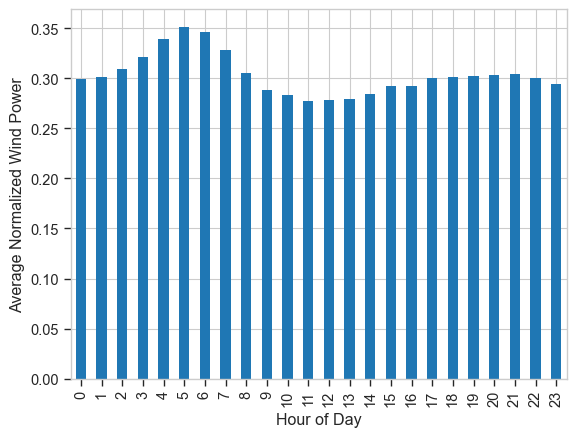

In [44]:
# 4.2 按小时分析：观察昼夜与功率的关系
df_train['hour'] = df_train['TIMESTAMP'].dt.hour
df_train.groupby('hour')['TARGETVAR'].mean().plot(kind='bar')
plt.xlabel('Hour of Day')
plt.ylabel('Average Normalized Wind Power')

## 5. 数值特征分析

<Axes: xlabel='TARGETVAR', ylabel='Count'>

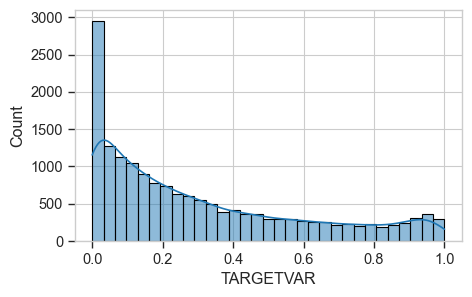

In [45]:
# 4.1 目标变量分布
fig, ax = plt.subplots(figsize=(5, 3))
sns.histplot(df_train['TARGETVAR'],kde=True)

array([[<Axes: title={'center': 'U10'}>, <Axes: title={'center': 'V10'}>],
       [<Axes: title={'center': 'U100'}>,
        <Axes: title={'center': 'V100'}>]], dtype=object)

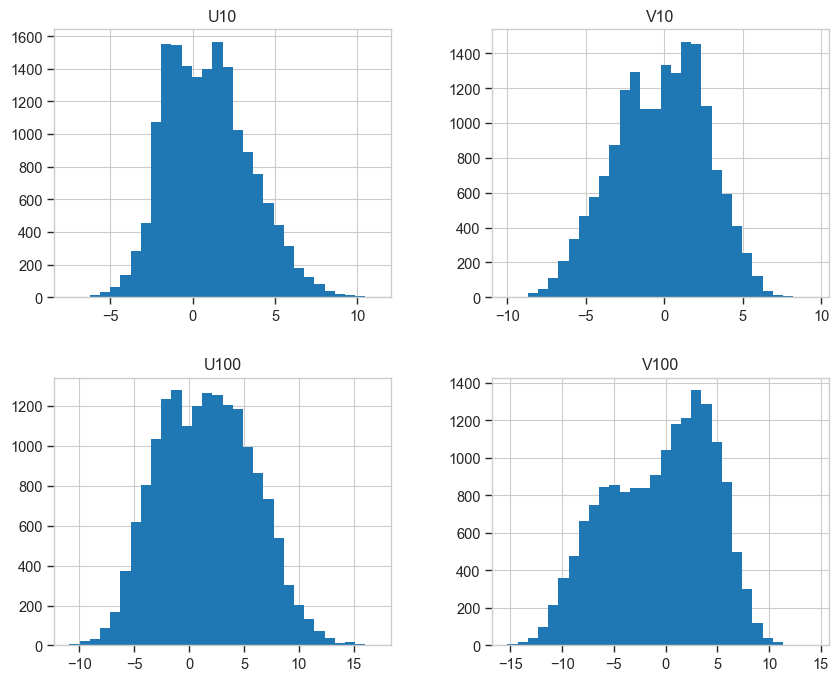

In [46]:
# 4.2 特征分布
df_train.hist(bins=30, figsize=(10,8),column=['U10', 'V10', 'U100', 'V100'])

## 5. 特征工程

In [47]:
# 5.1 构造：风速,风向

# 100米风速和风向
df_train['WindSpeed_100'] = np.sqrt(df_train['U100']**2 + df_train['V100']**2)
df_train['WindDirection_100'] = np.arctan2(df_train['V100'], df_train['U100']) * (180 / np.pi)

# 10米风速和风向
df_train['WindSpeed_10'] = np.sqrt(df_train['U10']**2 + df_train['V10']**2)
df_train['WindDirection_10'] = np.arctan2(df_train['V10'], df_train['U10']) * (180 / np.pi)

array([[<Axes: title={'center': 'WindSpeed_10'}>]], dtype=object)

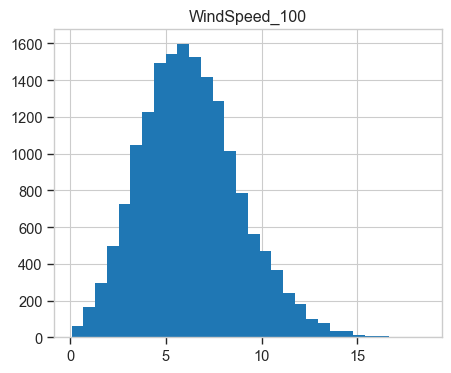

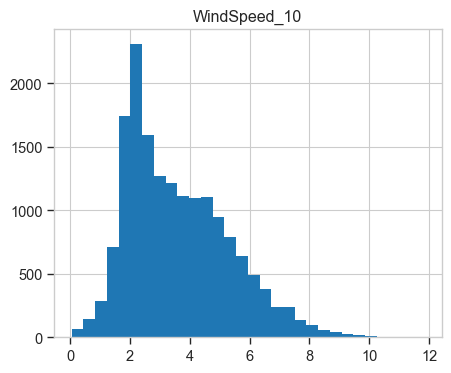

In [48]:
# 5.2 风速分布图
df_train.hist(bins=30, figsize=(5,4),column=['WindSpeed_100'])
df_train.hist(bins=30, figsize=(5,4),column=['WindSpeed_10'])

In [49]:
# 5.3 将风向（角度）映射到连续的周期空间（三角函数编码）

# 100米
df_train['WindDir_Sin_100'] = np.sin(df_train['WindDirection_100'] * np.pi / 180)
df_train['WindDir_Cos_100'] = np.cos(df_train['WindDirection_100'] * np.pi / 180)

# 10米
df_train['WindDir_Sin_10'] = np.sin(df_train['WindDirection_10'] * np.pi / 180) 
df_train['WindDir_Cos_10'] = np.cos(df_train['WindDirection_10'] * np.pi / 180)

In [50]:
# 5.4 增加一列特征：Theoretical_Power = Wind_Speed ** 3。
# 因为根据风力发电空气动力学，风功率与风速的三次方成正比。

# 100米
df_train['WindSpeed_100_cubed'] = df_train['WindSpeed_100'] ** 3

#10 米
df_train['WindSpeed_10_cubed'] = df_train['WindSpeed_10'] ** 3

In [59]:
# 5.5 计算特征与目标变量(TARGETVAR，即风电功率)的皮尔逊相关系数
correlation = df_train[['WindSpeed_100', 'WindSpeed_100_cubed', 
'WindSpeed_10', 'WindSpeed_10_cubed',
'WindDir_Sin_100', 'WindDir_Cos_100',
'WindDir_Sin_10', 'WindDir_Cos_10',
'TARGETVAR']].corr()
print("Correlation Matrix:\n", correlation)

Correlation Matrix:
                      WindSpeed_100  WindSpeed_100_cubed  WindSpeed_10  \
WindSpeed_100             1.000000             0.888691      0.905761   
WindSpeed_100_cubed       0.888691             1.000000      0.848227   
WindSpeed_10              0.905761             0.848227      1.000000   
WindSpeed_10_cubed        0.797837             0.930923      0.887302   
WindDir_Sin_100          -0.245723            -0.227826     -0.129402   
WindDir_Cos_100           0.214680             0.192763      0.254718   
WindDir_Sin_10           -0.223858            -0.217484     -0.108126   
WindDir_Cos_10            0.229621             0.201291      0.274672   
TARGETVAR                 0.740622             0.681180      0.705586   

                     WindSpeed_10_cubed  WindDir_Sin_100  WindDir_Cos_100  \
WindSpeed_100                  0.797837        -0.245723         0.214680   
WindSpeed_100_cubed            0.930923        -0.227826         0.192763   
WindSpeed_10     

<Axes: >

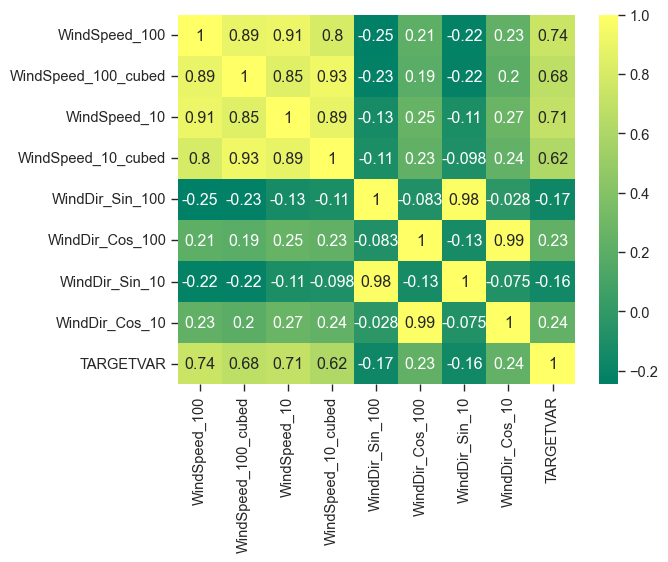

In [62]:
# 5.6 可视化相关矩阵
sns.heatmap(correlation, annot=True, cmap='summer')

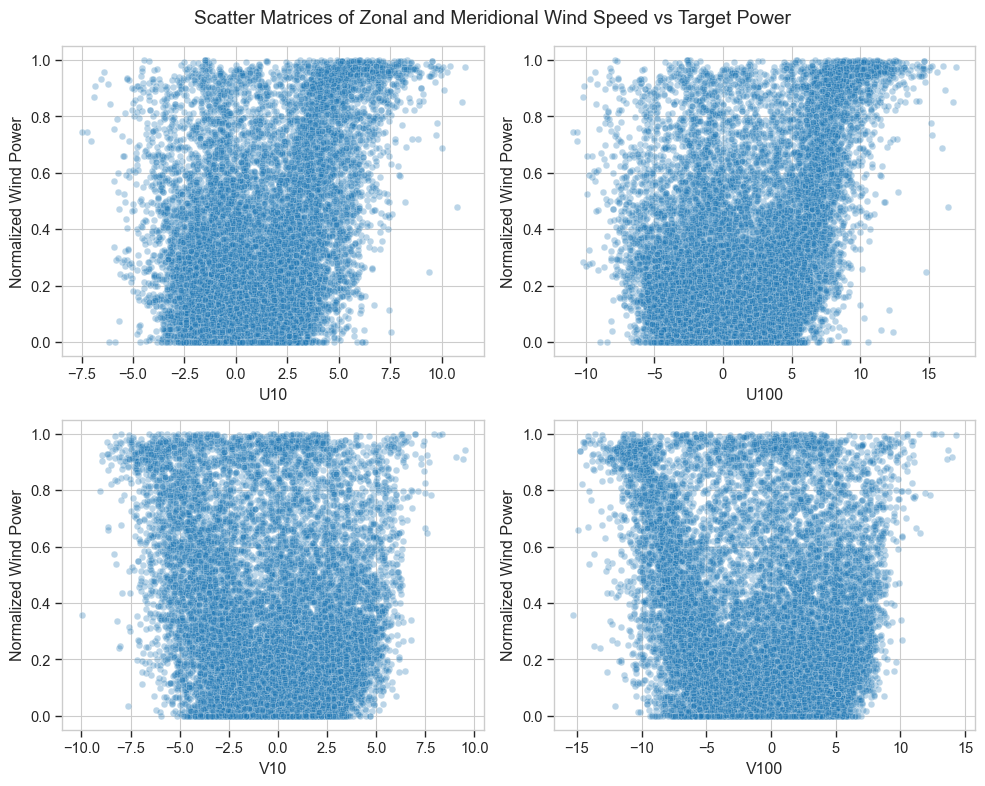

In [63]:
# 5.7 U10, U100, V10, V100与目标变量的散点图矩阵
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

cols = ['U10', 'U100', 'V10', 'V100']

for ax, col in zip(axes.flat, cols):
    sns.scatterplot(x=col, y='TARGETVAR', data=df_train, alpha=0.3, ax=ax)
    ax.set_xlabel(f'{col}')
    ax.set_ylabel("Normalized Wind Power")

plt.suptitle("Scatter Matrices of Zonal and Meridional Wind Speed vs Target Power")
plt.tight_layout()
plt.show()

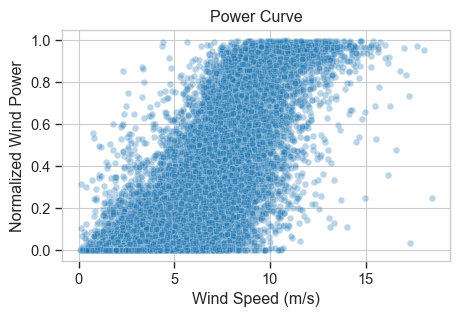

In [65]:
# 5.8 风速与目标变量的散点图
plt.figure(figsize=(5, 3))
sns.scatterplot(x='WindSpeed_100', y='TARGETVAR', data=df_train, alpha=0.3)
plt.title("Power Curve")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Normalized Wind Power")
plt.show()

## 7. 小结与建模前准备

#### 7.1 数据质量总结 
- 数据集共包含约 16,800 条样本，整体数据完整性较高
- TARGETVAR 存在少量缺失值（11条），已删除，对整体影响可忽略
- 未发现明显重复数据
- 数值特征分布基本合理，未发现严重异常值
- 风速相关特征（U/V分量）符合物理规律

#### 7.2 潜在特征及初步洞察 
- 风电功率与风速呈明显正相关关系，且为非线性关系
- 引入的 WindSpeed_100^3 能更好地刻画这种物理关系
- 风向本身是周期变量，使用 sin/cos 编码是合理的
- 不同高度（10m vs 100m）风速可能提供不同信息
- 风电功率存在一定的波动性和随机性（stochasticity）

#### 7.3 下一步建模建议 
- 模型选择：
    - Baseline: Linear Quantile Regression 
    - Tree-based: LightGBM
    - Advanced: LSTM
- 特征使用：原始特征 + 构造特征
- 数据划分策略：按时间划分训练集与测试集
- 评价指标：pinball loss （输出 P10, P50, P90 分位预测）